# Hopfield 1982：按论文顺序复现全部计算实验


**a 储存输入 → b 权重矩阵 → c 检索输入初态 → d 动力学检索 → e 测量指标 → f 展示**




## 0. 论文实验说明


| 类别 | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| a. 储存输入 | `a1` 随机记忆 | `a2` 指定汉明距离<br>的相似记忆 | `a3` 围绕共同原型<br>生成相关记忆 |  |  |  |
| b. 权重矩阵 | `b1` 标准 Hebb | `b2` 随机非对称 | `b3` 截断为符号 | `b4` 单向权重 | `b5` 饱和权重 | `b6` 加入序列项 |
| c. 检索输入初态 | `c1` 从指定记忆开始 | `c2` 随机状态 | `c3` 记忆加指定数量扰动 | `c4` 陌生状态 |  |  |
| d. 动力学检索 | `d1` 异步更新 | `d2` 同步更新 |  |  |  |  |
| e. 测量指标 | `e1` 汉明距离 | `e2` 最近吸引子 | `e3` 有效状态数 | `e4` 初始翻转率 | `e5` 最近记忆路径 |  |
| f. 展示 | `f1` 曲线图 | `f2` 柱状图 |  |  |  |  |

|实验|a|b|c|d|e / f|实验结论|
|---|---|---|---|---|---|---|
|1. 非对称动力学|跳过|`b2` 随机非对称|`c2` 随机|`d1`|`e3 + f2`|非对称网络不保证收敛；同一矩阵下可同时存在固定点和复杂持续动力学。|
|2. 存储容量|`a1`|`b1`|`c1`|`d1`|`e1 + f1`|随负载增加，召回从稳定逐渐转为快速恶化；约在 \(0.15N\) 附近出现明显容量压力|
|3. 随机初态落点|`a1`|`b1`|`c2`|`d1`|`e2 + f2`|大部分最终位于记忆或记忆附近，但伪吸引子不可忽略|
|4. 吸引盆纠错|`a1`|`b1`|`c3` 扰动|`d1`|`e2 + f1`|小扰动可以稳定纠正；距离增大后召回率下降|
|5. 截断权重|`a1`|`b1 → b3`|`c1`|`d1`|`e1 + f2`|截断权重与普通权重在低负载下表现接近，高负载下更快恶化|
|6. 单向连接|`a1`|`b1 → b4`|`c1`|`d1`|`e1 + f2`|删除一半方向后性能明显下降，但网络没有完全失效，符合 "软失效" 特征|
|7. 相似记忆融合|`a2`|`b1`|`c1`|`d1`|`e1 + e2 + f1`|记忆越接近，吸引子越容易偏移和融合|
|8. 过载熟悉度|`a1`，\(n=500\)|`b1`|`c1` 对比 `c4`|跳过完整动力学|`e4 + f2`|即使严重过载导致具体记忆无法稳定召回，陌生输入仍产生更高初始活动，可作为熟悉度信号|
|9. 时间序列|`a1`|`b1 → b6`|`c1`|`d1`|`e5 + f2`|弱序列项不能推动跳转；较强序列项只能实现一次转移，说明短序列可以出现，但长序列不可靠|





- numpy 创建数组  
  - `np.array(list) --> ndarray`  
    - 将列表转换为 numpy 数组  
    - eg: `np.array([-1,1]) --> array([-1, 1])`  
  - `np.zeros((N,N)) --> ndarray(N,N)`  
    - 创建指定形状的全零矩阵（此处为 N×N）  
    - eg: `np.zeros((2,2)) --> [[0,0],[0,0]]`  
  - `np.zeros_like(权重) --> ndarray`  
    - 创建与给定数组形状相同的全零矩阵  
    - eg: 权重是(3,3) --> 返回一个同样(3,3)的全零矩阵  
  - `np.ones(N) --> ndarray(N,)`  
    - 创建长度为 N 的全一向量  
    - eg: `np.ones(3) --> [1,1,1]`  
  - `np.arange(a,b) --> ndarray(b-a,)`  
    - 生成从 a 到 b-1 的整数序列（左闭右开）  
    - eg: `np.arange(1,5) --> [1,2,3,4]`  
  - `np.asarray(list) --> ndarray`  
    - 将输入转换为 ndarray（若已是数组则不变）  
    - eg: `np.asarray([1,2,3]) --> array([1,2,3])`

- 变形/组合  
  - `np.vstack([a,b]) --> ndarray`  
    - 垂直堆叠两个数组，行数相加  
    - eg: 记忆是(5,30)，`np.vstack([记忆,-记忆])` --> 变成(10,30)的矩阵，上半是原记忆下半是取反  
  - `np.repeat(原型, n, axis=0) --> ndarray(n,N)`  
    - 沿指定轴重复数组元素（此处沿行方向复制 n 次）  
    - eg: 原型是长度30的一维向量，复制5次 --> (5,30)的矩阵，五行完全一样  
  - `np.outer(a,b) --> ndarray(len(a),len(b))`  
    - 计算两个向量的外积  
    - eg: `np.outer([1,-1],[1,1]) --> [[1,1],[-1,-1]]`

- 统计/规约  
  - `np.sum(arr) --> 标量`  
    - 计算数组所有元素的和  
    - eg: `np.sum([1,2,3]) --> 6`  
  - `np.mean(arr) --> 标量`  
    - 计算数组所有元素的平均值  
    - eg: `np.mean([0,2,4]) --> 2.0`  
  - `np.count_nonzero(条件) --> 标量(int)`  
    - 统计数组中满足条件（非零）的元素个数，通常用于布尔数组统计 True 的个数  
    - eg: `a=[1,-1,1], b=[1,1,1]`，`np.count_nonzero(a!=b) --> 1`（只有中间那位不同）  
  - `np.diff(arr) --> ndarray`  
    - 计算相邻元素的差值，结果长度减 1  
    - eg: `np.diff([5,3,3,1]) --> [-2,0,-2]`  
  - `np.diag(权重) --> ndarray(N,)`  
    - 提取方阵的主对角线元素（若输入为矩阵）  
    - eg: 权重是(3,3) --> 取出主对角线上那3个数，变成长度3的一维数组  
  - `np.unique(arr, return_counts=True) --> (去重值, 各自计数)`  
    - 返回数组中的唯一值及其出现次数（若设置 return_counts）  
    - eg: `np.unique(['fixed','fixed','max_sweeps']) --> (['fixed','max_sweeps'], [2,1])`  
  - `np.argmin(arr) --> 标量(索引)`  
    - 返回最小值所在位置的索引（平坦化后的索引）  
    - eg: `np.argmin([5,1,3]) --> 1`（最小值1在下标1）  
  - `np.argsort(arr) --> ndarray`  
    - 返回排序后元素在原数组中的索引（从小到大）  
    - eg: `np.argsort([3,1,2]) --> [1,2,0]`（从小到大排，原来下标1的最小）

- 逐元素变换  
  - `np.sign(arr) --> ndarray`  
    - 返回每个元素的符号（正为 1，零为 0，负为 -1）  
    - eg: `np.sign([-2.5, 0, 3.1]) --> [-1., 0., 1.]`  
  - `np.clip(arr, 下限, 上限) --> ndarray`  
    - 将元素限制在给定区间内，超出部分截断  
    - eg: `np.clip([-5,0,5], -3,3) --> [-3,0,3]`  
  - `np.log(arr) --> ndarray`  
    - 计算每个元素的自然对数  
    - eg: `np.log([1, 2.718...]) --> [0., 1.]`

- 判断/比较  
  - `np.allclose(a,b) --> bool`  
    - 判断两个数组是否在容差范围内近似相等  
    - eg: `np.allclose([1.0000001],[1.0]) --> True`  
  - `np.array_equal(a,b) --> bool`  
    - 判断两个数组是否完全相等（形状和元素）  
    - eg: `np.array_equal([1,2],[1,2]) --> True`  
  - `np.all(arr) --> bool`  
    - 判断数组所有元素是否均为 True（或非零）  
    - eg: `np.all([True,True,False]) --> False`  
  - `np.isscalar(x) --> bool`  
    - 判断输入是否为 Python 标量（不是数组或列表）  
    - eg: `np.isscalar(5.0) --> True`；`np.isscalar([5.0]) --> False`

- 原地修改  
  - `np.fill_diagonal(权重, 值) --> None`  
    - 将方阵的主对角线全部赋为指定值，直接修改原数组，无返回值  
    - eg: 权重原本是 `[[9,1],[1,9]]`，调用 `np.fill_diagonal(权重,0)` 后权重变成 `[[0,1],[1,0]]`，没有返回值可接

- 类型标注（非函数调用）  
  - `np.int8`  
    - 一种数据类型标签，表示数组元素为 8 位有符号整数，常在 dtype 参数中使用  
    - eg: 无具体示例，用于类型声明  
  - `np.ndarray`  
    - numpy 数组的类型本身，用于类型注解中标注变量为 numpy 数组  
    - eg: 无具体示例，用于类型注解

- 随机数生成器  
  - `np.random.default_rng(种子) --> Generator对象`  
    - 创建一个可复现的随机数生成器，种子为整数（可选）  
    - eg: `np.random.default_rng(0) --> <一个可复现的随机数生成器>`  
  - `rng.choice(候选, size=形状) --> ndarray(形状)`  
    - 从候选中随机抽取元素，生成指定形状的数组  
    - eg: `rng.choice([-1,1], size=(2,3))` --> 一个2行3列、每格是-1或+1的矩阵（具体数字随种子变）  
  - `rng.integers(n) --> 标量(int)`  
    - 生成 0 到 n-1 之间的随机整数  
    - eg: `rng.integers(5) --> 一个0到4之间的整数，比如3`  
  - `rng.permutation(N) --> ndarray(N,)`  
    - 返回 0 到 N-1 的随机乱序排列  
    - eg: `rng.permutation(4) --> [2,0,3,1]`  
  - `rng.random((n,N)) --> ndarray(n,N)`  
    - 生成形状为 (n,N) 的均匀分布随机小数（0~1）  
    - eg: 生成一个2行2列、每格是0~1之间随机小数的矩阵，用于跟 flip_probability 比大小  
  - `rng.uniform(-1,1,size=(N,N)) --> ndarray(N,N)`  
    - 生成形状为 (N,N) 的均匀分布随机数，范围在 -1 到 1 之间  
    - eg: 生成一个N×N、每格在-1到1之间均匀分布的矩阵，就是 b2 的权重

- matplotlib 绘图  
  - `plt.style.use(风格名) --> None`  
    - 应用 matplotlib 绘图风格，全局副作用  
    - eg: 无具体示例，直接调用如 `plt.style.use('seaborn')`  
  - `plt.subplots(figsize=(宽,高)) --> (Figure对象, Axes对象)`  
    - 创建画布和坐标系，返回 Figure 和 Axes 对象  
    - eg: `fig, ax = plt.subplots(figsize=(7,4))` --> fig 是整张画布，ax 是画布上的一个坐标系  
  - `plt.show() --> None`  
    - 显示当前所有图形，渲染到屏幕  
    - eg: 无参数，直接调用  
  - `plt.tight_layout() --> None`  
    - 自动调整子图间距，防止重叠  
    - eg: 无参数，直接调用  
  - `plt.xticks(rotation=角度) --> None`  
    - 设置 x 轴刻度标签的旋转角度  
    - eg: `plt.xticks(rotation=45)`  
  - `ax.plot(x,y) --> None`  
    - 在指定坐标系上绘制折线图  
    - eg: `ax.plot([1,2],[3,4])` 画一条线  
  - `ax.bar(标签们, 数值们) --> None`  
    - 绘制柱状图  
    - eg: `ax.bar(['A','B'],[5,7])`  
  - `ax.set(xlabel=.., ylabel=.., title=..) --> None`  
    - 一次设置 x 轴标签、y 轴标签和标题  
    - eg: `ax.set(xlabel='x', ylabel='y', title='my plot')`  
  - `ax.set_ylabel(文字) --> None`  
    - 设置 y 轴标签  
    - eg: `ax.set_ylabel('accuracy')`  
  - `ax.set_title(文字) --> None`  
    - 设置子图标题  
    - eg: `ax.set_title('training loss')`  
  - `ax.tick_params(axis="x", labelrotation=0) --> None`  
    - 设置刻度参数，如旋转 x 轴标签  
    - eg: `ax.tick_params(axis="x", labelrotation=90)`  
  - `ax.legend() --> None`  
    - 显示图例（需先设置 label）  
    - eg: `ax.legend(loc='best')`

- math 模块  
  - `erfc(x) --> 标量(float)`  
    - 计算互补误差函数值  
    - eg: `erfc(0) --> 1.0`；`erfc(2) --> 约0.0047`  
  - `exp(x) --> 标量(float)`  
    - 计算自然指数 e^x  
    - eg: `exp(1) --> 约2.718`  
  - `sqrt(x) --> 标量(float)`  
    - 计算平方根  
    - eg: `sqrt(9) --> 3.0`

- typing / dataclasses（类型层面，无运行时输入输出）  
  - `Optional[X]`  
    - 类型注解，表示该参数可以是 X 类型或 None  
    - eg: 在函数定义中 `def f(x: Optional[int]) -> None:`  
  - `@dataclass`  
    - 装饰器，将类自动添加 `__init__`、`__repr__` 等方法  
    - eg: `@dataclass class Point: x: int; y: int`

- Python 内置函数  
  - `int(x) --> int`  
    - 将数值或字符串转换为整数（截断小数）  
    - eg: `int(3.7) --> 3`  
  - `float(x) --> float`  
    - 将数值或字符串转换为浮点数  
    - eg: `float('3.14') --> 3.14`  
  - `str(x) --> str`  
    - 将对象转换为字符串  
    - eg: `str(123) --> '123'`  
  - `tuple(可迭代对象) --> tuple`  
    - 将可迭代对象转换为元组  
    - eg: `tuple([1,2,3]) --> (1,2,3)`  
  - `list(可迭代对象) --> list`  
    - 将可迭代对象转换为列表  
    - eg: `list(range(3)) --> [0,1,2]`  
  - `dict() --> dict`  
    - 创建空字典或从键值对构造字典  
    - eg: `dict(a=1, b=2) --> {'a':1, 'b':2}`  
  - `set(可迭代对象) --> set`  
    - 将可迭代对象转换为集合（去重）  
    - eg: `set([1,1,2]) --> {1,2}`  
  - `len(容器) --> int`  
    - 返回容器的长度（元素个数）  
    - eg: `len([1,2,3]) --> 3`  
  - `range(a,b) --> range对象(可迭代)`  
    - 生成从 a 到 b-1 的整数序列（惰性）  
    - eg: `list(range(1,4)) --> [1,2,3]`  
  - `zip(a,b) --> zip对象(可迭代的配对)`  
    - 将多个可迭代对象按元素配对  
    - eg: `list(zip([1,2],[3,4])) --> [(1,3),(2,4)]`  
  - `print(x) --> None`  
    - 将内容打印到控制台，副作用  
    - eg: `print('hello')` 输出 hello  
  - `round(x, 位数) --> float`  
    - 对浮点数四舍五入到指定小数位数  
    - eg: `round(3.14159,2) --> 3.14`


## 1. 公共实验组件

这一节只定义公共机制。首次打开或修改组件后，请执行 **Runtime → Restart session and run all**，避免 notebook 的旧状态污染结果。

### 1.1 环境、结果对象与随机数


In [21]:
from dataclasses import dataclass
from math import erfc, exp, sqrt
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")


@dataclass
class DynamicsResult:

    final_state: np.ndarray #(N,) -- 迭代结束时的状态
    sweeps: int             # 用了几轮/几步收敛（或到达上限）
    status: str             # 收敛方式，"fixed"/"cycle2"/"max_sweeps"/"max_steps"，
    flips_per_sweep: tuple[int, ...]# 每轮翻转次数，用于观察收敛速度，不参与后续计算
    state_history: Optional[list[np.ndarray]] = None #仅在显式要求时才非空，默认不保存，避免占内存
    energy_history: Optional[list[float]] = None


SEED = 0
# 全局默认种子，顶层实验没显式传别的种子时兜底


### 1.2 a：记忆生成

- `a1`：相互独立的随机记忆。
- `a2`：构造一对具有指定汉明距离的相似记忆。
- `a3`：围绕共同原型生成相关记忆。


In [22]:
def a1_make_independent_memories(
    n: int,
    N: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    输入 n -- 要生成的记忆条数；N -- 每条记忆的维度
    输出 memories:(n,N) -- n 条相互独立的随机 ±1 记忆
    """
    return rng.choice(np.array([-1, 1], dtype=np.int8), size=(n, N))
    # [输入] 从 {-1,+1} 里独立采样，是后续所有存储/召回实验的起点


def a2_make_memories_with_close_pair(
    n: int,
    N: int,
    distance: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    输入 n,N 同上；distance -- 最后一条记忆要跟第一条相差的比特数
    输出 memories:(n,N) -- 前 n-1 条互相独立，最后一条是第一条的近邻
    """
    if n < 2:
        raise ValueError("n 至少为 2")
        # [约束] 构造"一对相似记忆"至少要有两条记忆可比较

    memories = a1_make_independent_memories(n=n, N=N, rng=rng)
    # [中介变量] 先按完全随机生成，最后一条马上会被覆盖，只是占位

    memories[-1] = memories[0].copy()
    #［构造］在一堆随机记忆里，精确制造一对 特别相似的记忆，这里选第一条和最后一条，先拷贝

    flip_indices = rng.choice(N, size=distance, replace=False)
    # [中介变量] flip_indices:(distance,) -- 要翻转的比特位置，无放回抽样保证不重复翻同一位

    memories[-1, flip_indices] *= -1
    # [更新] 只翻这 distance 个位置，翻转后与 memories[0] 的汉明距离恰好等于 distance
    return memories


def a3_make_prototype_correlated_memories(
    n: int,
    N: int,
    flip_probability: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """
    输入 n,N 同上；flip_probability -- 每条记忆相对原型独立翻转每一位的概率
    输出 memories:(n,N) -- n 条共享同一原型、带统计相关性的记忆
         prototype:(N,) -- 共同原型，本身不是任何一条实际记忆
    """
    prototype = a1_make_independent_memories(n=1, N=N, rng=rng)[0]
    # [中介变量] 原型:(N,) -- 随机基准点

    memories = np.repeat(prototype[None, :], n, axis=0)
    # 把原型复制 n 份

    flip_mask = rng.random((n, N)) < flip_probability
    # [中介变量] flip_mask:(n,N) 布尔矩阵 -- 每个位置独立决定是否翻转：

    memories[flip_mask] *= -1
    # [更新] 按布尔矩阵 原地翻转对应位置
    return memories, prototype


### 1.3 b：权重构造与变换

`b1` 是标准 Hebb 权重；`b3`–`b6` 都是显式变换，因此实验代码能直接显示在标准权重上增加了什么。


In [23]:
def b1_make_hebbian_weights(memories: np.ndarray) -> np.ndarray:
    """
    输入 memories:(n,N) -- n 条已生成好的记忆
    输出 weights:(N,N) -- 标准 Hebb 权重矩阵
    """
    weights = memories.astype(float).T @ memories.astype(float)
    # [存储] memories.T:(N,n) @ memories:(n,N) --> weights:(N,N)
    # [中介变量] astype(float)：来源 memories(int8)，用途防溢出(n=500 时求和会溢出)

    np.fill_diagonal(weights, 0.0)
    # [约束] T_ii=0。无自反馈，
    return weights


def b2_make_random_asymmetric_weights(
    N: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    输入 N -- 神经元数
    输出 weights:(N,N) -- 无监督生成的随机权重，Tij 与 Tji 无关，用来测试对称性假设是否必要
    """
    weights = rng.uniform(-1.0, 1.0, size=(N, N))
    # [输入] 均匀采样，跟任何记忆无关
    np.fill_diagonal(weights, 0.0)
    # [约束] T_ii=0
    return weights


def b3_binarize_weights(weights: np.ndarray) -> np.ndarray:
    """
    输入 weights:(N,N) -- 任意已算好的权重（ b1 的输出）
    输出 binarized:(N,N) -- 每个非零元素被压成 ±1，只保留符号
    """
    binarized = np.sign(weights)
    # [更新] weights:(N,N) --> clipped:(N,N)，逐元素去数值取符号±1，这是式(3)"截断"的定义
    np.fill_diagonal(binarized, 0.0)
    # [约束] 显式再清一次对角线，保证截断后 T_ii=0 依然成立
    return binarized


def b4_keep_one_direction_per_pair(
    weights: np.ndarray,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    输入 weights:(N,N) -- 对称 Hebb 权重
    输出 one_way:(N,N) -- 每对 (i,j) 只保留一个方向的连接，模拟真实突触的单向性
    """
    one_way = np.zeros_like(weights)
    # [中介变量] one_way:(N,N)，先全零占位，逐对 (i,j) 填入
    N = weights.shape[0]
    for i in range(N):
        for j in range(i + 1, N):
            # [实验控制] 只遍历上三角 (i<j)，因为每一对只决定一次方向
            if rng.random() < 0.5:
                one_way[i, j] = weights[i, j]
                # [更新] 保留 i→j 方向，j→i 方向保持为 0
            else:
                one_way[j, i] = weights[j, i]
                # [更新] 保留 j→i 方向，i→j 方向保持为 0
    return one_way


def b5_add_memory_with_saturation(
    weights: np.ndarray,
    memory: np.ndarray,
    limit: int = 3,
) -> np.ndarray:
    """
    输入 weights:(N,N) -- 当前累积权重；memory:(N,) -- 新来的一条记忆；limit -- 权重绝对值上限
    输出 updated:(N,N) -- 叠加新记忆并截幅后的权重
    """
    updated = weights + np.outer(memory, memory)
    # [更新] memory:(N,) 外积 memory:(N,) --> (N,N)，逐步累加，等价于持续学习
    np.fill_diagonal(updated, 0)
    # [约束] T_ii=0
    return np.clip(updated, -limit, limit)
    # [约束] 权重饱和在 [-limit, limit]。这是"自然遗忘"机制本身：
    # 旧记忆的贡献会被后续更新的 +1/-1 增量逐渐挤出这个有限区间


def b6_add_asymmetric_sequence_terms(
    weights: np.ndarray,
    memories: np.ndarray,
    strength: float,
) -> np.ndarray:
    """
    输入 weights:(N,N) -- 已有的对称 Hebb 权重；memories:(n,N) -- 要按顺序串起来的记忆序列；
        strength -- 序列项的强度 A
    输出 sequenced:(N,N) -- 叠加了非对称"下一条记忆"提示项的权重
    """
    sequenced = weights.astype(float).copy()
    # [中介变量] 复制而非原地改，避免污染调用者传入的 weights
    for current, following in zip(memories[:-1], memories[1:]):
        # [实验控制] 依次取相邻的 (V^s, V^{s+1}) 记忆对
        sequenced += strength * np.outer(following, current)
        # [更新] 式(13) ΔTij = A(2V^{s+1}_i-1)(2V^s_j-1)
        # following:(N,) 外积 current:(N,) --> (N,N)，following 在前、current 在后，
        # 这样局部场里 j 是"当前记忆"时才会推 i 往"下一条记忆"走，方向不能写反
    np.fill_diagonal(sequenced, 0.0)
    # [约束] T_ii=0
    return sequenced


### 1.4 c：初始状态


In [24]:
def c1_start_from_memory(
    memories: np.ndarray,
    index: int,
) -> np.ndarray:
    """
    输入 memories:(n,N)；index -- 选第几条记忆当初始状态
    输出 state:(N,) -- 该记忆的副本
    """
    return memories[index].copy()
    # [输入] 复制，不是引用——避免后续 d1 原地修改污染 memories 数组


def c2_random_state(
    N: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    输入 N -- 维度
    输出 state:(N,) -- 跟任何记忆都无关的随机初态
    """
    return rng.choice(np.array([-1, 1], dtype=np.int8), size=N)
    # [输入] 用来测试"网络会漂到哪个吸引子"，跟 a1 生成记忆用的是同一种采样

# 扰动
def c3_perturb_memory(
    memory: np.ndarray,
    n_flips: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    输入 memory:(N,) -- 一条干净记忆；n_flips -- 要翻转的比特数
    输出 state:(N,) -- 与 memory 相距恰好 n_flips 比特的初态
    """
    state = memory.copy()
    indices = rng.choice(memory.size, size=n_flips, replace=False)
    # [中介变量] indices:(n_flips,) -- 无放回抽样，保证真的翻了 n_flips 个不同位置
    state[indices] *= -1
    # [更新] 精确控制初始汉明距离，这是实验4"吸引盆半径"的自变量
    return state


def c4_unfamiliar_state(
    N: int,
    rng: np.random.Generator,
) -> np.ndarray:
    """
    输入 N；输出 state:(N,) -- "陌生输入"
    """
    return c2_random_state(N=N, rng=rng)
    # 这一步在问：c4 跟 c2 代码完全一样，为什么还要单独起个名字？
    # 答案：生成方式相同，但实验语境不同——c2 是"随便一个初态"，
    # c4 是"故意构造一个跟任何记忆都不像的输入"，命名区分的是实验意图，不是算法


### 1.5 d：动力学

`d1_run_async` 默认只返回终态和轻量摘要。只有明确设置 `record_states=True` 或 `record_energy=True` 时才保存过程数据。

注意：能量单调性只适用于对称权重。非对称实验不得把 `record_energy=True` 当作收敛证明。


In [25]:
def _measure_energy(weights: np.ndarray, state: np.ndarray) -> float:
    """
    输入 weights:(N,N)；state:(N,)
    输出 标量 -- 式(7)定义的能量，仅在对称权重下单调不增，是观测量不是判据
    """
    return float(-0.5 * state @ weights @ state)
    # [观测·数据] 能量值；state:(N,) @ weights:(N,N) @ state:(N,) --> 标量
    # d1/d2 从不读这个函数的返回值来决定是否继续迭代，纯粹是外部拿来验证收敛性质用的尺子


def _resolve_threshold(threshold: float | np.ndarray, i: int) -> float:
    """
    输入 threshold -- 标量或长度 N 的数组；i -- 神经元编号
    输出 标量 -- 神经元 i 应用的阈值
    """
    return float(threshold if np.isscalar(threshold) else threshold[i])
    # [中介变量] 统一接口：调用方不用关心 threshold 到底是全局统一还是逐神经元


def d1_run_async(
    weights: np.ndarray,
    initial_state: np.ndarray,
    rng: np.random.Generator,
    max_sweeps: int = 50,
    threshold: float | np.ndarray = 0.0,
    record_states: bool = False,
    record_energy: bool = False,
) -> DynamicsResult:
    """
    输入 weights:(N,N) -- 已存好记忆的突触矩阵
        initial_state:(N,) -- 当前观察到的、可能带噪声的状态
    输出 final_state:(N,) -- 迭代到不动点(或到达 max_sweeps)后的状态
    异步：每个神经元的更新立刻生效，同一轮内后面的神经元能看到前面的更新
    """
    state = initial_state.copy()
    # [中介变量] initial_state:(N,) --> state:(N,)，复制是为了不污染调用者传入的数组
    state_history = [state.copy()] if record_states else None
    # [观测·数据] 状态轨迹；默认 None，只有显式要求才保存完整轨迹，避免长时间实验内存爆掉
    energy_history = [_measure_energy(weights, state)] if record_energy else None
    # [观测·数据] 能量轨迹；同上，且只在对称权重下这条曲线才保证单调
    flips_per_sweep: list[int] = []
    # [中介变量] 每轮翻转次数的累计列表，用于观察收敛速度

    for sweep in range(1, max_sweeps + 1):
        flips = 0
        # [中介变量] 本轮计数器，只用于判停

        for i in rng.permutation(state.size):
            # [中介变量] i:标量，本轮更新顺序，来源随机数生成器
            # 为什么不按 0..N-1 固定顺序？—— 固定顺序会让结果依赖神经元编号本身，
            # "异步"要的就是这份随机

            local_field = weights[i] @ state - _resolve_threshold(threshold, i)
            # [更新] 式(2)左边；weights[i]:(N,); state:(N,) --> local_field:标量
            # 这一步在问：神经元 i 现在翻转，会不会更符合它记得的模式？
            # local_field 就是"其余神经元投票 i 该是+1还是-1"的净票数

            new_value = 1 if local_field > 0 else -1 if local_field < 0 else state[i]
            # [判断] local_field:标量 --> new_value:标量
            # 全文唯一非线性：票数过半就翻，没过半不翻，恰好为0时保持原值(阈值处不定义的边界约定)

            if new_value != state[i]:
                state[i] = new_value
                # [存储] 原地覆盖，立刻生效——这是异步和 d2 同步版本的分界线
                flips += 1
                # [中介变量] 计数器递增
                if record_states:
                    state_history.append(state.copy())
                    # [观测·数据] 状态快照；只在显式要求时才追加，逐次翻转记录，比逐轮记录更细
                if record_energy:
                    energy_history.append(_measure_energy(weights, state))
                    # [观测·数据] 能量快照；同上

        flips_per_sweep.append(flips)
        # [中介变量] 记录本轮总翻转数

        if flips == 0:
            # [判断] 一整轮没有任何神经元翻转 = 到达不动点
            return DynamicsResult(
                final_state=state,
                sweeps=sweep,
                status="fixed",
                flips_per_sweep=tuple(flips_per_sweep),
                state_history=state_history,
                energy_history=energy_history,
            )

    return DynamicsResult(
        final_state=state,
        sweeps=max_sweeps,
        status="max_sweeps",
        # [判断] 到达轮数上限仍未收敛，可能是周期或混沌游走(见实验1)
        flips_per_sweep=tuple(flips_per_sweep),
        state_history=state_history,
        energy_history=energy_history,
    )


def d2_run_sync(
    weights: np.ndarray,
    initial_state: np.ndarray,
    max_steps: int = 100,
    record_states: bool = False,
) -> DynamicsResult:
    """
    输入 weights:(N,N)；initial_state:(N,)
    输出 final_state:(N,) -- 同步更新版本，作为论文外机制对照，不是论文本身用的算法
    同步：本轮所有神经元一起根据"上一轮"的状态决定新值，因此可能出现二周期
    """
    state = initial_state.copy()
    previous = None
    # [中介变量] 保存上一轮状态，用于检测二周期(A→B→A→B)
    state_history = [state.copy()] if record_states else None
    flips_per_step: list[int] = []

    for step in range(1, max_steps + 1):
        local_fields = weights @ state
        # [更新] weights:(N,N) @ state:(N,) --> local_fields:(N,)
        # 一次性对所有神经元算局部场，用的全是上一轮的 state，
        # 这跟 d1 逐个用"当前最新 state"算，是同步和异步的根本区别

        new_state = state.copy()
        new_state[local_fields > 0] = 1
        new_state[local_fields < 0] = -1
        # [判断] local_fields:(N,) --> new_state:(N,)，逐元素判决，一次性全部生效

        flips_per_step.append(int(np.count_nonzero(new_state != state)))
        # [中介变量] 统计本步翻转数，仅观测用
        if record_states:
            state_history.append(new_state.copy())
            # [观测·数据] 状态快照

        if np.array_equal(new_state, state):
            # [判断] 与上一状态相同 = 不动点
            return DynamicsResult(
                new_state, step, "fixed", tuple(flips_per_step), state_history
            )
        if previous is not None and np.array_equal(new_state, previous):
            # [判断] 与上上一状态相同 = 二周期，同步更新特有的失败模式，异步版本不会出现
            return DynamicsResult(
                new_state, step, "cycle2", tuple(flips_per_step), state_history
            )
        previous = state.copy()
        # [中介变量] 滚动保存"上一轮"状态供下一次判周期用
        state = new_state

    return DynamicsResult(
        state, max_steps, "max_steps", tuple(flips_per_step), state_history
    )


### 1.6 e：测量

过程型指标尽量在线累计，不默认保存完整轨迹。`e4_initial_flip_rate` 只执行指定次数的神经元更新尝试，正好对应论文的初始处理速率。


In [26]:
def e1_hamming_distance(
    state_a: np.ndarray,
    state_b: np.ndarray,
) -> int:
    """
    输入 state_a,state_b:(N,)
    输出 标量 -- 不同比特位的个数
    """
    return int(np.count_nonzero(state_a != state_b))
    # [观测·数据] 汉明距离；逐元素比较后计数，是最基础的召回误差量尺


def e2_identify_attractor(
    state: np.ndarray,
    memories: np.ndarray,
) -> tuple[int, int]:
    """
    输入 state:(N,) -- 网络当前状态；memories:(n,N) -- 候选记忆集合(可以是名义记忆也可以是±memories)
    输出 (index, distance) -- 离 state 最近的那条记忆的编号和距离
    """
    distances = np.count_nonzero(memories != state, axis=1)
    # [观测·数据] 逐条记忆的汉明距离；memories:(n,N) != state:(N,) 广播比较 --> (n,N) 布尔 --> axis=1 求和 --> (n,)
    index = int(np.argmin(distances))
    # [判断] 取距离最小的那条
    return index, int(distances[index])


def e3_effective_state_count(
    state_history: list[np.ndarray],
) -> float:
    """
    输入 state_history -- d1 record_states=True 时保存的轨迹
    输出 标量 M -- 式(9)有效状态数 exp(熵)，用来量化"游走覆盖了多大范围"
    """
    if not state_history:
        return 0.0
    counts: dict[bytes, int] = {}
    # [中介变量] 用状态的字节表示做字典键，统计每个不同状态出现了几次
    for state in state_history:
        key = state.astype(np.int8, copy=False).tobytes()
        # [中介变量] ndarray 本身不能当字典键(不可哈希)，转成 bytes 才能计数
        counts[key] = counts.get(key, 0) + 1

    probabilities = np.array(list(counts.values()), dtype=float)
    probabilities /= probabilities.sum()
    # [中介变量] 频次归一化成经验概率分布 p_i

    entropy = -float(np.sum(probabilities * np.log(probabilities)))
    # [观测·结果] 熵；式(9) ln M = -Σ p_i ln p_i 的右边先算出熵
    return exp(entropy)
    # [观测·结果] 有效状态数 M；熵取指数还原成"等效状态数" M


def e4_initial_flip_rate(
    weights: np.ndarray,
    initial_state: np.ndarray,
    rng: np.random.Generator,
    attempts: int,
    threshold: float = 0.0,
) -> float:
    """
    输入 weights,initial_state 同 d1；attempts -- 只尝试更新这么多次，不跑到收敛
    输出 标量 -- 这 attempts 次尝试里翻转的比例，即论文"初始处理速率"
    """
    state = initial_state.copy()
    flips = 0
    order = rng.permutation(state.size)[:attempts]
    # [中介变量] order:(attempts,) -- 只取全排列的前 attempts 个，不跑完整轮
    # 这一步在问：为什么不像 d1 那样跑到收敛？—— 论文测的是"网络第一眼反应有多剧烈"，
    # 收敛后的终态对熟悉/陌生已经不敏感了，信号藏在最初那几步里

    for i in order:
        local_field = weights[i] @ state - threshold
        # [更新] 同 d1 的局部场公式，但这里 threshold 只支持标量
        new_value = 1 if local_field > 0 else -1 if local_field < 0 else state[i]
        # [判断]
        if new_value != state[i]:
            state[i] = new_value
            # [存储]
            flips += 1
    return flips / attempts
    # [观测·结果] 初始翻转率；翻转比例，越熟悉的输入这个值理论上越低(局部场已经跟记忆对齐，不太需要翻)


def e5_nearest_memory_path(
    state_history: list[np.ndarray],
    memories: np.ndarray,
) -> list[int]:
    """
    输入 state_history -- 轨迹；memories:(n,N)
    输出 path -- 依次经过的、且与上一个不同的最近记忆编号序列
    """
    path: list[int] = []
    for state in state_history:
        index, _ = e2_identify_attractor(state, memories)
        # [观测·数据] 当前最近记忆编号；每一帧都判一次"当前离哪条记忆最近"
        if not path or path[-1] != index:
            path.append(index)
            # [中介变量] 只在编号发生变化时才追加，把长轨迹压缩成"经过了哪些记忆区域"
    return path


def theoretical_bit_error_probability(n: int, N: int) -> float:
    """
    输入 n -- 存储记忆数；N -- 维度
    输出 标量 -- 式(10)单比特出错概率的高斯近似
    """
    if n <= 1:
        return 0.0
        # [约束] 只存 1 条记忆时没有交叉干扰项，误差恒为0
    sigma = sqrt((n - 1) * N / 2)
    # [中介变量] 式(10)里噪声项的标准差 σ = [(n-1)N/2]^(1/2)
    return 0.5 * erfc((N / 2) / (sigma * sqrt(2)))
    # [观测·结果] 理论单比特出错概率；高斯尾部概率，用互补误差函数算，是理论曲线，不是模拟结果


### 1.7 f：展示


In [27]:
def f1_plot_curve(
    x,
    series: dict[str, list[float] | np.ndarray],
    xlabel: str,
    ylabel: str,
    title: str,
):
    """
    输入 x -- 横轴取值；series -- {曲线名: 纵轴值}，可以同时画多条线
    输出 无返回值，直接 plt.show()
    """
    fig, ax = plt.subplots(figsize=(7, 4))
    for label, values in series.items():
        ax.plot(x, values, marker="o", label=label)
        # [展示] 纯画图，不影响任何实验数值
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title)
    if len(series) > 1:
        ax.legend()
    plt.show()


def f2_plot_bar(
    labels,
    values,
    ylabel: str,
    title: str,
):
    """
    输入 labels -- 类别名；values -- 对应柱高
    输出 无返回值
    """
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(labels, values)
    # [展示]
    ax.set(ylabel=ylabel, title=title)
    plt.xticks(rotation=0, ha="center")
    plt.show()


## 2. 公共组件自检

这些检查在跑论文实验前先验证：编码只能是 $\{-1,+1\}$、Hebb 权重对称且对角线为零、异步更新时对称系统的能量不增加、轨迹默认不保存、同步更新能识别二周期。


In [28]:
rng = np.random.default_rng(SEED)
memories = a1_make_independent_memories(n=5, N=30, rng=rng)
weights = b1_make_hebbian_weights(memories)
initial_state = c3_perturb_memory(memories[0], n_flips=4, rng=rng)
run = d1_run_async(
    weights,
    initial_state,
    rng,
    record_energy=True,
)

assert set(np.unique(memories)) <= {-1, 1}
# [约束检验] 编码只能是 {-1,+1}
assert set(np.unique(run.final_state)) <= {-1, 1}
# [约束检验] 动力学不会产生编码之外的值
assert np.allclose(weights, weights.T)
# [约束检验] Hebb 权重对称
assert np.allclose(np.diag(weights), 0)
# [约束检验] 对角线为零
assert run.state_history is None
# [约束检验] 默认不保存轨迹(这次调用没传 record_states=True)
assert np.all(np.diff(run.energy_history) <= 1e-9)
# [约束检验] 对称权重下能量单调不增，允许 1e-9 的浮点误差

cycle_weights = np.array([[0.0, 1.0], [1.0, 0.0]])
# [输入] 手工构造一个最小反例：两个神经元互相正向连接
cycle_run = d2_run_sync(
    cycle_weights,
    np.array([1, -1], dtype=np.int8),
)
assert cycle_run.status == "cycle2"
# [约束检验] 同步更新下这个反例必然产生二周期，验证 d2 能正确识别它

print("公共组件自检通过")


公共组件自检通过


## 3. 实验1：非对称随机连接的动力学行为（组A：对称性假设检验）


**问题**：移除 $T_{ij}=T_{ji}$ 后，随机初态会收敛、进入周期，还是在局部区域游走？

**配方**：`b2 → c2 → d1 → e3 → f2`

论文使用 $N=30$ 和 $N=100$。下面先重复 50 个随机初态，再单独记录一次过程轨迹；密集重复部分不保存轨迹。论文这一段使用 $\{0,1\}$ 状态与零阈值；转换到代码的 $\{-1,+1\}$ 状态后，等价阈值必须变成每行权重和的相反数，而不能继续直接写成零。


In [ ]:
rng = np.random.default_rng(2)
N = 30

# ========== 1. 权重构造（b2，本实验唯一"非标准"的一步）==========
weights = b2_make_random_asymmetric_weights(
    # *[输入] 本实验的自变量：随机非对称权重（对照标准对称 Hebb 权重）
    N=N,
    rng=rng,
)
# [输入] 完全独立于任何记忆的随机权重，Tij 与 Tji 无关联


# ========== 2. 编码换算（{0,1}→{-1,+1} 的阈值补偿）==========
threshold = -weights.sum(axis=1)
# [编码翻译] 论文原文用 {0,1} 编码、U=0；这里代码统一用 {-1,+1}，
# 两种编码下同一个物理阈值对应不同数值，这行是换算公式本身，不是"调参"


# ========== 3. 主循环：50 次独立试验（c2 → d1）==========
# 补全说明：d1_run_async 的 status 只区分 "fixed" / "max_sweeps"，没有循环检测，
# 要区分论文说的三种行为（固定点/简单循环/混沌漫游），必须对每条"未收敛"轨迹
# 都留下 state_history，事后用 e3 的有效状态数 M 做二次分类，不能只挑一条当样本。
statuses = []
non_fixed_state_histories = []
# [中介变量] 全部非固定点轨迹都留

for _ in range(50):
    initial_state = c2_random_state(N=N, rng=rng)
    # [输入] 每次试验换一个随机初态

    run = d1_run_async(
        weights=weights,
        initial_state=initial_state,
        rng=rng,
        max_sweeps=50,
        threshold=threshold,
        record_states=True,
        # *[实验控制] 每条轨迹都记录，不再只挑第一条非固定点做样本
    )

    statuses.append(run.status)
    if run.status != "fixed":
        non_fixed_state_histories.append(run.state_history)
        # [中介变量] 只有非固定点轨迹才需要留着做二次分类


# ========== 4. 二次分类：M 值分档（固定点/简单循环/混沌漫游）==========
CYCLE_LIKE_M_THRESHOLD = 10
# [约束·可执行定义] 简单循环 vs 混沌漫游没有论文给的硬数值分界，这里选10：
# 严格 k 步循环理论上 M 应在个位数(A→B→A→B 型 M≈2)，混沌漫游的 M 会明显更大。
# 这是我们自己定的判据，不是论文原文数字。

category_counts = {"fixed point": 0, "simple cycle-like": 0, "chaotic wandering": 0}
non_fixed_diagnostics = []
# [中介变量] 每条非固定点轨迹的 (M, χ) 一起存，供最后打印分布用

for status in statuses:
    if status == "fixed":
        category_counts["fixed point"] += 1
        # [判断]

for history in non_fixed_state_histories:
    M = e3_effective_state_count(history)
    # [观测·数据] 有效状态数 M(式9)，熵加权的"访问过多少不同状态"

    total_steps = len(history)
    unique_states = len(set(state.astype(np.int8).tobytes() for state in history))
    chi = 1.0 - (unique_states / total_steps)
    # [观测·数据] 混沌系数 χ：1 - 去重状态数/总步数，越接近0越混沌，是 M 的一个更简单的
    # 替代量尺(χ 只看"重复没重复"，不像 M 那样按访问频率加权熵，两者方向一致、量纲不同)

    non_fixed_diagnostics.append((M, chi))

    if M <= CYCLE_LIKE_M_THRESHOLD:
        category_counts["simple cycle-like"] += 1
        # [判断] M 小，接近周期性重复
    else:
        category_counts["chaotic wandering"] += 1
        # [判断] M 大，访问状态数多、接近均匀


# ========== 5. 画图展示（f2_plot_bar，三分类）==========
f2_plot_bar(
    list(category_counts.keys()),
    list(category_counts.values()),
    ylabel="Number of initial states",
    title="Dynamics with random asymmetric weights (3-way classification)",
)
print(category_counts)

if non_fixed_diagnostics:
    M_values = [d[0] for d in non_fixed_diagnostics]
    chi_values = [d[1] for d in non_fixed_diagnostics]
    print(
        f"非固定点轨迹 M 值分布：min={min(M_values):.1f}, "
        f"median={sorted(M_values)[len(M_values)//2]:.1f}, max={max(M_values):.1f}"
    )
    print(
        f"非固定点轨迹 χ(混沌系数) 分布：min={min(chi_values):.4f}, "
        f"median={sorted(chi_values)[len(chi_values)//2]:.4f}, max={max(chi_values):.4f}"
    )
else:
    print("本次50次试验全部收敛到固定点")


**对照论文**：论文报告最常见行为是稳定点，也偶见二周期与局部混沌游走；$N=30$ 的一次局部游走得到有效状态数 $M=25$。这里的数值会随随机矩阵和观测时长变化，重点是复现行为类型，而不是强求同一个 $M$。


## 4. 实验2：存储容量与信噪比（组B：容量扫描）

**原文定位**：论文 pp.2556–2557，图2；原文从 “Computer modeling” 开始描述容量模拟。

**问题**：当 $N=100$ 时，随着存储记忆数 $n$ 增加，正确召回如何下降？

**配方**：`a1 → b1 → c1 → d1 → e1 → f1`

每次试验都重新生成记忆和权重，运行后只保留终态误差；不会累计状态轨迹。


In [ ]:
rng = np.random.default_rng(102)
N = 100
n_values = np.arange(1, 21)
# *[输入] 本实验的自变量：存储的记忆条数 n，从1扫到20
trials_per_n = 50
mean_errors = []
exact_rates = []
theory_exact_rates = []
errors_by_n = {}
# [中介变量] 只为图2风格直方图准备的容器，跟原有曲线计算无关
# [中介变量] 三条累积序列，长度都会跟 n_values 对齐，供最后画图用

for n in n_values:
    errors = []
    for _ in range(trials_per_n):
        memories = a1_make_independent_memories(n=n, N=N, rng=rng)
        weights = b1_make_hebbian_weights(memories)
        # [存储] 每次试验都重新生成记忆和权重，不复用上一次的，避免结果被单一随机矩阵污染

        target_index = int(rng.integers(n))
        initial_state = c1_start_from_memory(memories, target_index)
        # [输入] 从存储的记忆本身出发，测的是"能不能守住自己存过的东西"

        run = d1_run_async(weights, initial_state, rng)
        errors.append(e1_hamming_distance(run.final_state, memories[target_index]))
        # [观测·数据] 单次试验的错误比特数；收敛后跟原记忆差几个比特

    errors = np.asarray(errors)
    if n in (5, 10, 15):
        errors_by_n[int(n)] = errors.copy()
        # [观测·数据] 保留 n=5/10/15 的逐次试验原始误差，供论文图2风格直方图使用
    mean_errors.append(float(errors.mean()))
    exact_rates.append(float(np.mean(errors == 0)))
    # [观测·结果] 精确召回率；errors==0 表示零误差精确召回，取比例

    bit_error = theoretical_bit_error_probability(n=n, N=N)
    theory_exact_rates.append((1 - bit_error) ** N)
    # [观测·结果] 理论精确召回率；理论曲线：单比特都不错的概率 = (1-单比特出错率)^N，跟模拟曲线对照

f1_plot_curve(
    n_values,
    {
        "Simulation: exact recall": exact_rates,
        "Gaussian approximation": theory_exact_rates,
    },
    xlabel="Number of stored memories n",
    ylabel="Exact recall probability",
    title="Hopfield storage capacity",
)
print("n=5,10,15 的平均错误位数：", {
    n: round(mean_errors[n - 1], 2) for n in (5, 10, 15)
})


# ========== 补充：论文图2 三面板直方图（N=100, n=5/10/15 的 Nerr 分布）==========
# 论文原图是三个堆叠的直方图面板，不是曲线；f1/f2 都不支持多面板，这里手写。
NERR_BIN_EDGES = [0, 3, 6, 9, 10, 20, 30, 40, 50, N + 1]
# [约束·可执行定义] 论文原图分箱边界描述模糊，这里取一个覆盖 0~N 的合理分箱，
# 不是论文原图的精确复刻，是同一种"错误位数分布"的可执行近似

fig, axes = plt.subplots(len(errors_by_n), 1, figsize=(7, 8), sharex=True)
for ax, n in zip(axes, sorted(errors_by_n)):
    ax.hist(errors_by_n[n], bins=NERR_BIN_EDGES, density=True)
    # [展示]
    ax.set_ylabel(f"n={n}\nProbability")
axes[-1].set_xlabel("Nerr = 状态中的错误数")
fig.suptitle("Error distribution at recalled fixed points (paper Fig.2 style)")
plt.tight_layout()
plt.show()


**对照论文**：论文报告 $n=5$ 时记忆几乎总是稳定；在 $n=15\approx0.15N$ 时，约一半记忆仍接近原记忆，另一半严重失真。有限试验次数和随机种子会造成曲线波动。


## 5. 实验3：随机初态的吸引子分布（组C：检索鲁棒性）

**原文定位**：论文 p.2557，“Given some arbitrary starting state …” 段落。

**问题**：随机初态最终落入指定记忆、记忆附近，还是伪吸引子？

**配方**：`a1 → b1 → c2 → d1 → e2 → f2`


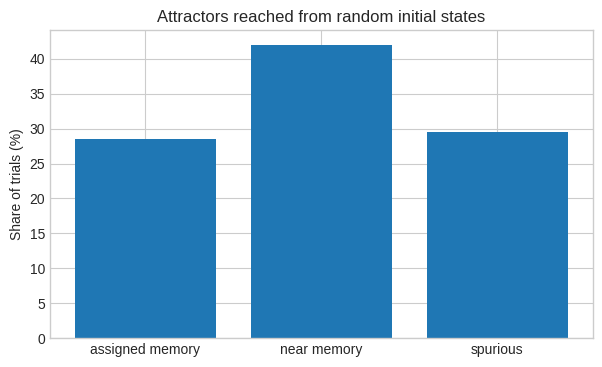

{'assigned memory': 57, 'near memory': 84, 'spurious': 59}


In [31]:
rng = np.random.default_rng(103)
N, n, trials = 30, 5, 200
memories = a1_make_independent_memories(n=n, N=N, rng=rng)
weights = b1_make_hebbian_weights(memories)

nominal_attractors = np.vstack([memories, -memories])
# [中介变量] nominal_attractors:(2n,N) -- 论文里 Vi→-Vi 全局对称，-memories 同样是稳定点，
# 判"落到哪个吸引子"时必须把这些也算进候选，否则会把合法的负版本误判成伪吸引子

outcomes = {"assigned memory": 0, "near memory": 0, "spurious": 0}

for _ in range(trials):
    initial_state = c2_random_state(N=N, rng=rng)
    # *[输入] 本实验的自变量：随机初态（对照从记忆本身出发）

    run = d1_run_async(weights, initial_state, rng)
    _, distance = e2_identify_attractor(run.final_state, nominal_attractors)
    # [观测·数据] 到最近名义吸引子的距离；只要距离，不要具体编号

    if distance == 0:
        outcomes["assigned memory"] += 1
        # [判断] 精确落在某条名义记忆(或其负版本)上
    elif distance <= 2:
        outcomes["near memory"] += 1
        # [判断] "附近"的可执行定义：不超过2比特
    else:
        outcomes["spurious"] += 1
        # [判断] 落到了论文没有存过的伪吸引子

f2_plot_bar(
    list(outcomes),
    [100 * value / trials for value in outcomes.values()],
    ylabel="Share of trials (%)",
    title="Attractors reached from random initial states",
)
print(outcomes)


**对照论文**：论文一次统计约为 85% 指定记忆、10% 无明显意义的稳定态、5% 记忆附近状态。这里使用“距名义吸引子不超过 2 bit”作为“附近”的可执行定义。


## 6. 实验4：吸引盆与纠错能力（组C：检索鲁棒性）

**原文定位**：论文 p.2557，“partially random starting states” 段落。

**问题**：从已存记忆翻转多少 bit 后，网络仍能回到最近的原记忆？

**配方**：`a1 → b1 → c3 → d1 → e2 → f1`


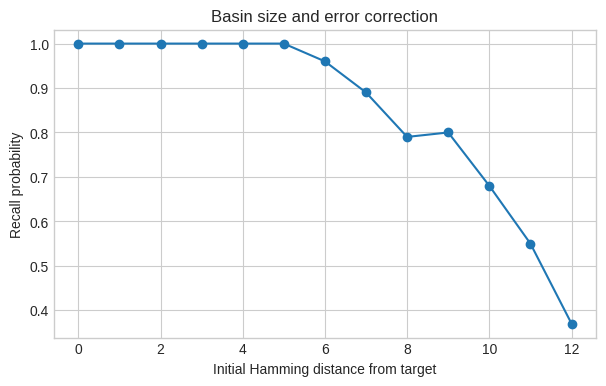

In [32]:
rng = np.random.default_rng(104)
N, n = 30, 5
distances = np.arange(0, 13)
# *[输入] 本实验的自变量：初始扰动的汉明距离，从0扫到12
trials_per_distance = 100
memories = a1_make_independent_memories(n=n, N=N, rng=rng)
weights = b1_make_hebbian_weights(memories)
recall_rates = []

for distance in distances:
    successes = 0
    for _ in range(trials_per_distance):
        target_index = int(rng.integers(n))
        initial_state = c3_perturb_memory(
            memories[target_index],
            n_flips=int(distance),
            rng=rng,
        )
        # [输入] 精确控制起点离目标记忆有多远

        run = d1_run_async(weights, initial_state, rng)
        nearest_index, _ = e2_identify_attractor(run.final_state, memories)
        # [观测·数据] 终态最近的记忆编号；只关心落到哪条记忆最近，不关心具体距离

        successes += int(nearest_index == target_index)
        # [判断] 是否回到了"出发时那条"记忆，而不是随便一条记忆
    recall_rates.append(successes / trials_per_distance)

f1_plot_curve(
    distances,
    {"Return to target memory": recall_rates},
    xlabel="Initial Hamming distance from target",
    ylabel="Recall probability",
    title="Basin size and error correction",
)


**对照论文**：论文报告距离不超过 5 bit 时返回最近记忆的概率超过 90%，距离 12 时下降到约 0.2。随机记忆集合不同会明显改变单次曲线。


## 7. 实验5：截断权重（组D：存储机制鲁棒性）

**原文定位**：论文 p.2557，“clipped $T_{ij}$” 段落。

**问题**：把 Hebb 权重压成 $\{-1,0,+1\}$ 后，容量和误差怎样变化？

**配方**：`a1 → b1+b3 → c1 → d1 → e1 → f2`


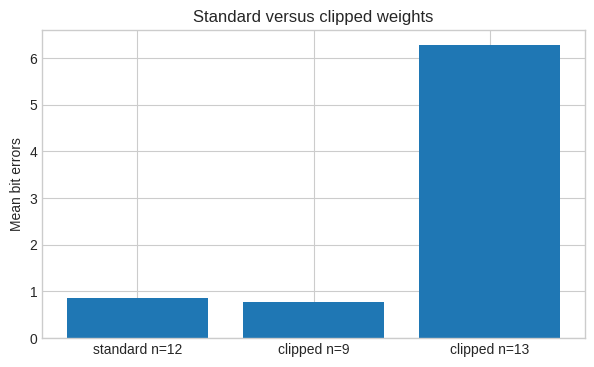

In [33]:
rng = np.random.default_rng(105)
N, trials = 100, 100
conditions = [
# *[输入] 本实验的自变量：是否截断权重 + 负载 n 的组合，三组对照
    ("standard n=12", 12, False),
    ("clipped n=9", 9, True),
    ("clipped n=13", 13, True),
]
# [输入] 三组对照：普通权重用较少记忆(12)，截断权重分别测低负载(9)和号称的最优负载(13)
condition_errors = []

for _, n, clipped in conditions:
    errors = []
    for _ in range(trials):
        memories = a1_make_independent_memories(n=n, N=N, rng=rng)
        weights = b1_make_hebbian_weights(memories)
        if clipped:
            weights = b3_binarize_weights(weights)
            # [更新] 只在这一分支把权重压成 {-1,0,+1}，标准分支保持浮点权重不变

        target_index = int(rng.integers(n))
        initial_state = c1_start_from_memory(memories, target_index)
        run = d1_run_async(weights, initial_state, rng)
        errors.append(e1_hamming_distance(run.final_state, memories[target_index]))
    condition_errors.append(float(np.mean(errors)))

f2_plot_bar(
    [name for name, _, _ in conditions],
    condition_errors,
    ylabel="Mean bit errors",
    title="Standard versus clipped weights",
)


**对照论文**：论文报告 $N=100$ 时，截断权重的 $n=9$ 与普通权重的 $n=12$ 错误水平相近；截断权重的最大 Shannon 信息量约出现在 $n=13$。


## 8. 机制扩展1：有限权重与自然遗忘（组D：存储机制鲁棒性）

**原文定位**：论文 p.2557，“The saturation of the possible size” 段落。

**问题**：权重限制在 $0,\pm1,\pm2,\pm3$ 时，新记忆是否逐渐覆盖旧记忆？

**配方**：`a1 → b5 → c1 → d1 → e1 → f1`


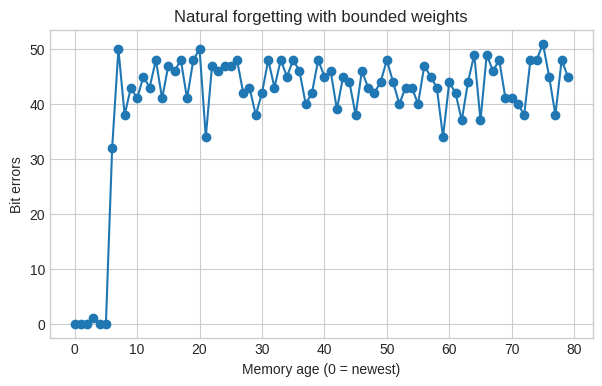

In [34]:
rng = np.random.default_rng(106)
N, stream_length = 100, 80
memory_stream = a1_make_independent_memories(n=stream_length, N=N, rng=rng)
# [输入] 一次性生成80条记忆，模拟"依次到来"的记忆流

weights = np.zeros((N, N), dtype=float)
# [中介变量] 权重从零开始累积，不是一次性 Hebb 算好的

for memory in memory_stream:
    weights = b5_add_memory_with_saturation(weights, memory, limit=3)
    # *[更新] 本实验的自变量：饱和截幅的权重累积；越晚加入的记忆影响越大

ages = np.arange(stream_length - 1, -1, -1)
# [中介变量] 把记忆流的位置转换成"年龄"：最后加入的记忆年龄为0(最新)，最早加入的年龄最大

errors_by_age = []
for memory in memory_stream:
    initial_state = c1_start_from_memory(memory[None, :], 0)
    # [编码翻译] c1 要求二维数组做索引，这里单条记忆临时升维成 (1,N) 再取第0条

    run = d1_run_async(weights, initial_state, rng)
    errors_by_age.append(e1_hamming_distance(run.final_state, memory))
    # [观测·数据] 单条记忆的召回误差；拿饱和后的最终权重，逐条测每条记忆现在还能不能被稳定召回

order = np.argsort(ages)
# [中介变量] 排序索引，因为 memory_stream 是按时间顺序而不是年龄顺序排的

f1_plot_curve(
    ages[order],
    {"Recall error": np.asarray(errors_by_age)[order]},
    xlabel="Memory age (0 = newest)",
    ylabel="Bit errors",
    title="Natural forgetting with bounded weights",
)


**解释**：这是论文给出的硬件机制演示，不是带完整统计表的独立实验。曲线应总体表现为旧记忆更容易失真，但单条随机记忆会有波动。


## 9. 实验6：单向连接与软失效（组D：存储机制鲁棒性）

**原文定位**：论文 p.2557，“Simulations were carried out with only one ij connection” 段落。

**问题**：若每对神经元只保留一个连接方向，稳定记忆是否仍存在？

**配方**：`a1 → b1+b4 → c1 → d1 → e1 → f2`


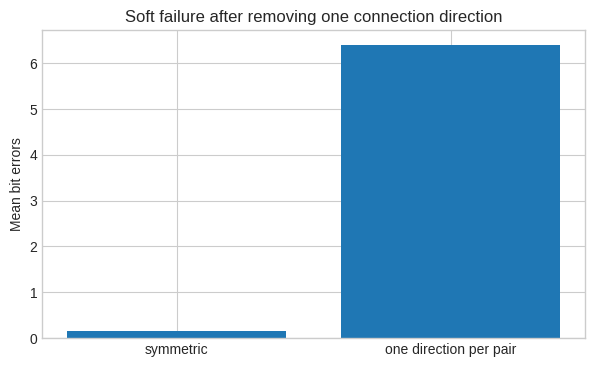

In [35]:
rng = np.random.default_rng(107)
N, n, trials = 100, 10, 100
errors = {"symmetric": [], "one direction per pair": []}

for _ in range(trials):
    memories = a1_make_independent_memories(n=n, N=N, rng=rng)
    symmetric = b1_make_hebbian_weights(memories)
    one_way = b4_keep_one_direction_per_pair(symmetric, rng)
    # *[更新] 本实验的自变量：是否只保留单向连接
    # 差异只来自"是否保留双向连接"这一个变量

    target_index = int(rng.integers(n))
    initial_state = c1_start_from_memory(memories, target_index)
    # [中介变量] 两个条件共用同一个初始状态，进一步控制变量

    for label, weights in [
        ("symmetric", symmetric),
        ("one direction per pair", one_way),
    ]:
        run = d1_run_async(weights, initial_state, rng)
        errors[label].append(
            e1_hamming_distance(run.final_state, memories[target_index])
        )
        # [观测·数据] 单次试验的错误比特数；同一个起点，两种权重各自跑一遍，误差直接可比

f2_plot_bar(
    list(errors),
    [float(np.mean(values)) for values in errors.values()],
    ylabel="Mean bit errors",
    title="Soft failure after removing one connection direction",
)


**对照论文**：论文观察到错误率提高，但算法仍产生稳定极小值；信噪比按约 $1/\sqrt{2}$ 降低，而不是突然完全失效。


## 10. 实验7：相似记忆的混淆与融合（组E：记忆集合内部结构）

**原文定位**：论文 p.2557，$N=100,n=8$，令第八条记忆与另一条的汉明距离为 30、20 或 10。

**问题**：两条记忆太相似时，它们保持分离、发生偏移，还是融合成同一吸引子？

**配方**：`a2 → b1 → c1 → d1 → e1/e2 → f1`


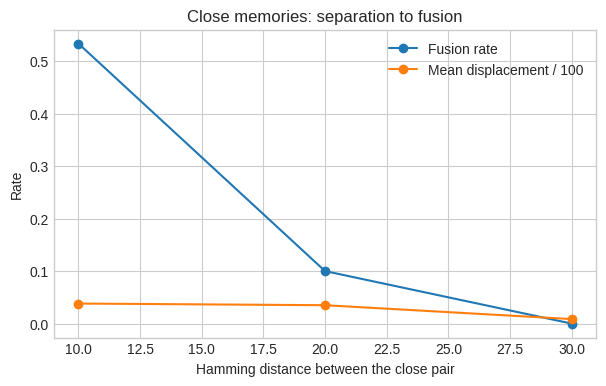

In [36]:
rng = np.random.default_rng(108)
N, n, trials = 100, 8, 60
distances = [30, 20, 10]
# *[输入] 本实验的自变量：那对相似记忆之间的汉明距离，论文点名的三个档位
fused_rates = []
displaced_errors = []

for distance in distances:
    fused = 0
    total_error = 0
    for _ in range(trials):
        memories = a2_make_memories_with_close_pair(
            n=n,
            N=N,
            distance=distance,
            rng=rng,
        )
        # [存储] 前 n-1 条互相独立，最后一条精确地跟第一条相距 distance

        weights = b1_make_hebbian_weights(memories)
        run_a = d1_run_async(
            weights,
            c1_start_from_memory(memories, 0),
            rng,
        )
        run_b = d1_run_async(
            weights,
            c1_start_from_memory(memories, n - 1),
            rng,
        )
        # [中介变量] run_a、run_b 分别从这对相似记忆各自出发，看它们会不会收敛到同一个点

        fused += int(np.array_equal(run_a.final_state, run_b.final_state))
        # [判断] 两个终态完全相同 = 融合成了同一个吸引子

        total_error += (
            e1_hamming_distance(run_a.final_state, memories[0])
            + e1_hamming_distance(run_b.final_state, memories[-1])
        ) / 2
        # [观测·数据] 终态相对原记忆的偏移量；即使没融合，也测一下终态相对各自原记忆偏移了多少

    fused_rates.append(fused / trials)
    displaced_errors.append(total_error / trials)

f1_plot_curve(
    distances,
    {
        "Fusion rate": fused_rates,
        "Mean displacement / 100": np.asarray(displaced_errors) / 100,
        # [展示] 除以100纯粹是让两条曲线数值量级接近，方便共用一个纵轴看
    },
    xlabel="Hamming distance between the close pair",
    ylabel="Rate",
    title="Close memories: separation to fusion",
)


**对照论文**：距离 30 时通常都稳定；距离 20 时极小值通常仍分离但位置偏移；距离 10 时经常融合。


## 11. 机制扩展2：阈值与“不熟悉”状态（组C：检索鲁棒性）

**原文定位**：论文 p.2557，讨论统一阈值如何让静默状态成为可能的稳定态。

**问题**：提高阈值后，与任何记忆都不像的输入是否更容易落入全静默状态？

**编码提醒**：论文 $\{0,1\}$ 编码中的 `0000…`，在这里的 $\{-1,+1\}$ 编码中对应全 `-1`。

**配方**：`a1 → b1 → c1/c4 → d1 → e2 → f1`


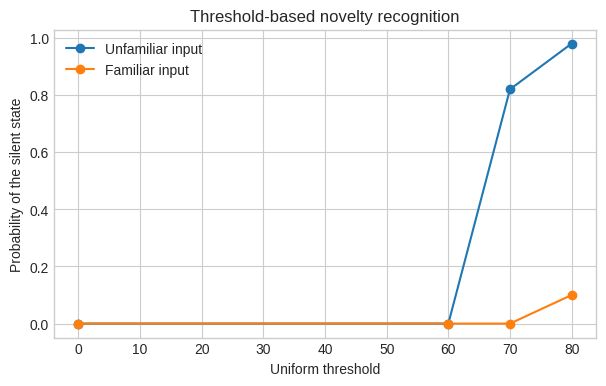

In [37]:
rng = np.random.default_rng(109)
N, n, trials = 100, 5, 100
memories = a1_make_independent_memories(n=n, N=N, rng=rng)
weights = b1_make_hebbian_weights(memories)
silent_state = -np.ones(N, dtype=np.int8)
# [编码翻译] 论文 {0,1} 编码里的全 0000... 状态，在 {-1,+1} 编码下对应全 -1
threshold_values = [0.0, 60.0, 70.0, 80.0]
# *[输入] 本实验的自变量：统一阈值
unfamiliar_silent_rates = []
familiar_silent_rates = []

for threshold in threshold_values:
    unfamiliar_silent = 0
    familiar_silent = 0
    for _ in range(trials):
        unfamiliar_state = c4_unfamiliar_state(N=N, rng=rng)
        unfamiliar_run = d1_run_async(
            weights,
            unfamiliar_state,
            rng,
            threshold=threshold,
        )
        _, distance = e2_identify_attractor(
            unfamiliar_run.final_state,
            silent_state[None, :],
        )
        # [编码翻译] e2 要求候选记忆是二维数组，silent_state 临时升维成 (1,N)
        unfamiliar_silent += int(distance == 0)
        # [判断] 终态精确等于全静默状态

        familiar_index = int(rng.integers(n))
        familiar_state = c1_start_from_memory(memories, familiar_index)
        familiar_run = d1_run_async(
            weights,
            familiar_state,
            rng,
            threshold=threshold,
        )
        _, distance = e2_identify_attractor(
            familiar_run.final_state,
            silent_state[None, :],
        )
        familiar_silent += int(distance == 0)
        # [中介变量] 同样的判定逻辑，但起点换成熟悉输入，作对照组

    unfamiliar_silent_rates.append(unfamiliar_silent / trials)
    familiar_silent_rates.append(familiar_silent / trials)

f1_plot_curve(
    threshold_values,
    {
        "Unfamiliar input": unfamiliar_silent_rates,
        "Familiar input": familiar_silent_rates,
    },
    xlabel="Uniform threshold",
    ylabel="Probability of the silent state",
    title="Threshold-based novelty recognition",
)


**解释**：这是阈值机制的可执行演示。阈值的数值依赖编码和权重是否归一化，不能直接把这里的数值与论文 $\{0,1\}$ 记号逐字等同。


## 12. 实验8：严重过载下的熟悉度识别（组C：检索鲁棒性）

**原文定位**：论文 p.2558，$N=100,n=500$，过载约 25 倍。

**问题**：当所有记忆都不再是稳定点时，能否通过初始处理速率区分熟悉与陌生输入？

**配方**：`a1 → b1 → c1/c4 → e4 → f2`

这里不保存轨迹，只在线统计前 $N/2$ 次更新尝试中的翻转比例。


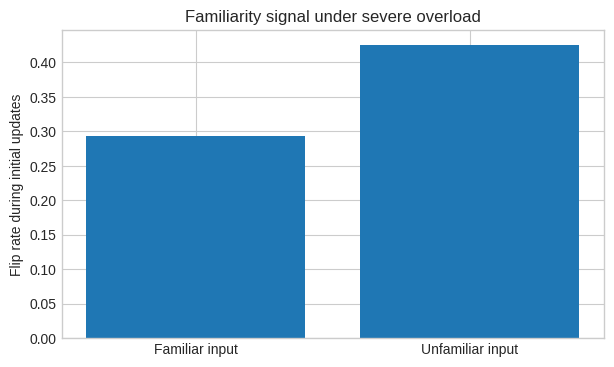

熟悉=0.293, 陌生=0.426


In [38]:
rng = np.random.default_rng(110)
N, n, trials = 100, 500, 100
# *[输入] 本实验的固定条件：n=500 远超容量估计(0.15N≈15)，刻意制造严重过载
memories = a1_make_independent_memories(n=n, N=N, rng=rng)
weights = b1_make_hebbian_weights(memories)
familiar_rates = []
unfamiliar_rates = []

for _ in range(trials):
    familiar_index = int(rng.integers(n))
    familiar_state = c1_start_from_memory(memories, familiar_index)
    unfamiliar_state = c4_unfamiliar_state(N=N, rng=rng)
    familiar_rates.append(
        e4_initial_flip_rate(
            weights,
            familiar_state,
            rng,
            attempts=N // 2,
        )
    )
    # [观测·数据] 初始翻转率；只看前 N/2 次更新尝试的翻转比例，不等收敛——过载下终态已经没有意义了

    unfamiliar_rates.append(
        e4_initial_flip_rate(
            weights,
            unfamiliar_state,
            rng,
            attempts=N // 2,
        )
    )

f2_plot_bar(
    ["Familiar input", "Unfamiliar input"],
    [float(np.mean(familiar_rates)), float(np.mean(unfamiliar_rates))],
    ylabel="Flip rate during initial updates",
    title="Familiarity signal under severe overload",
)
print(
    f"熟悉={np.mean(familiar_rates):.3f}, "
    f"陌生={np.mean(unfamiliar_rates):.3f}"
)


**对照论文**：论文报告陌生状态的初始处理速率通常更快，因此即使不能召回具体记忆，网络仍保留熟悉度信号。


## 13. 机制扩展3：相关记忆与部分信息补全（组E：记忆集合内部结构）

**原文定位**：论文 p.2558，式 (11)–(12)。

**问题**：若记忆共享统计相关性，部分输入是否会被补全为符合共同结构的状态？

**配方**：`a3 → b1 → c3 → d1 → e1 → f2`


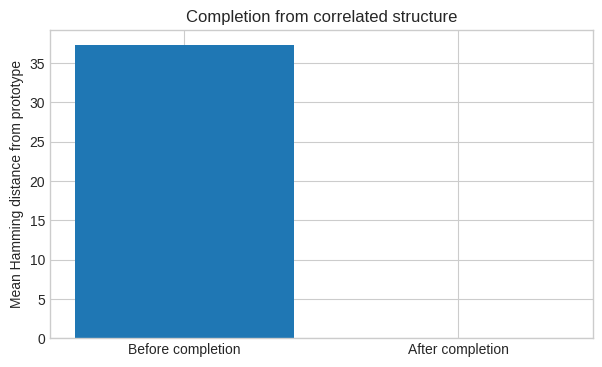

In [39]:
rng = np.random.default_rng(111)
N, n, trials = 100, 30, 100
memories, prototype = a3_make_prototype_correlated_memories(
    n=n,
    N=N,
    flip_probability=0.2,
    rng=rng,
)
# [存储] 30条记忆都是同一个 prototype 加20%概率翻转得到的，彼此高度相关

weights = b1_make_hebbian_weights(memories)
before = []
after = []

for _ in range(trials):
    target_index = int(rng.integers(n))
    initial_state = c3_perturb_memory(
        memories[target_index],
        n_flips=30,
        rng=rng,
    )
    # [输入] 从某条具体记忆出发，但故意扰动掉30个比特(约30%)

    before.append(e1_hamming_distance(initial_state, prototype))
    # [观测·数据] 补全前到原型的距离；补全前，起点离"原型"多远

    run = d1_run_async(weights, initial_state, rng)
    after.append(e1_hamming_distance(run.final_state, prototype))
    # [观测·数据] 补全后到原型的距离；补全后，终态离"原型"多远——对照对象是 prototype 不是 target_index，
    # 这是在测"网络有没有把输入拉向共同结构"，不是测能不能召回具体那条记忆

f2_plot_bar(
    ["Before completion", "After completion"],
    [float(np.mean(before)), float(np.mean(after))],
    ylabel="Mean Hamming distance from prototype",
    title="Completion from correlated structure",
)


**解释**：论文这里给出的是相关矩阵下的机制推演，不是完整统计实验。本节用共同原型构造相关性，展示同一思想；它不是式 (11)–(12) 的逐项精确复刻。


## 14. 实验9：时间序列记忆（组D：存储机制鲁棒性）

**原文定位**：论文 p.2558，式 (13)，紧邻 *Discussion* 之前。

**问题**：向 Hebb 权重加入从当前记忆指向下一记忆的非对称项，能否让状态按顺序跳转？

**配方**：`a1 → b1+b6 → c1 → d1 → e5 → f2`


A=0.2: 最近记忆路径 [0], status=fixed
A=0.5: 最近记忆路径 [0], status=fixed
A=1.0: 最近记忆路径 [0, 1], status=fixed


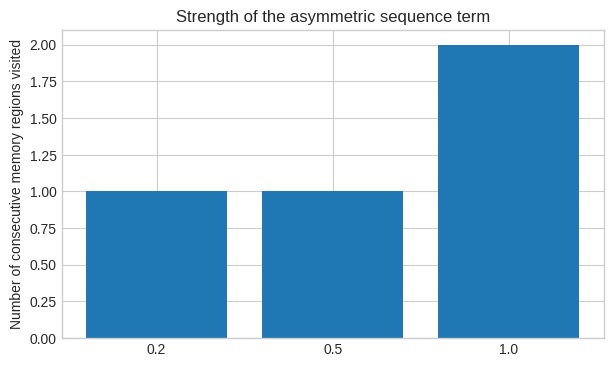

In [40]:
rng = np.random.default_rng(112)
N, n = 100, 4
memories = a1_make_independent_memories(n=n, N=N, rng=rng)
base_weights = b1_make_hebbian_weights(memories)
# [存储] 先算好普通对称权重，序列项在下面单独叠加，方便对比不同强度

strengths = [0.2, 0.5, 1.0]
# *[输入] 本实验的自变量：序列项强度 A（论文式13），扫描三个档位
path_lengths = []

for strength in strengths:
    weights = b6_add_asymmetric_sequence_terms(
        base_weights,
        memories,
        strength=strength,
    )
    # [更新] 每个强度档位都从同一个 base_weights 出发叠加，不会累积上一次循环的序列项

    initial_state = c1_start_from_memory(memories, 0)
    # [输入] 固定从第一条记忆出发，看它能不能被推着往后面的记忆走

    run = d1_run_async(
        weights,
        initial_state,
        rng,
        max_sweeps=20,
        record_states=True,
        # [实验控制] 这里必须记录轨迹，因为要看"经过了哪几条记忆"而不只是终态
    )
    path = e5_nearest_memory_path(run.state_history, memories)
    # [观测·数据] 最近记忆路径；把整条轨迹压缩成"依次经过的记忆编号序列"
    path_lengths.append(len(path))
    print(f"A={strength}: 最近记忆路径 {path}, status={run.status}")

f2_plot_bar(
    [str(value) for value in strengths],
    path_lengths,
    ylabel="Number of consecutive memory regions visited",
    title="Strength of the asymmetric sequence term",
)


**对照论文**：论文观察到适当强度可使系统在 $V^s$ 附近停留后移向 $V^{s+1}$，但超过四个状态的序列难以生成，即使短序列也不完全可靠。
